# S7a_Lyell_melt_progression_2020.ipynb

Lyell basin melt-phase progression, 2020 (S1-Rc): spatial melt-phase maps for
S1-Rc, SnowModel-baseline, and SnowModel-precip-corrected, basin-integrated
phase fractions, streamflow, and WRF air temperature/precipitation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import os
import importlib
import sys
import rioxarray as rxr
from pathlib import Path
import xarray as xr
import pandas as pd


# gets rid of a lot of annoying warnings, we know there are NaNs (might want to remove this to double check)
import warnings
warnings.filterwarnings("ignore")


In [2]:
sys.path.insert(1, '../scripts/')

In [3]:
import metadata as metadata


In [4]:
import importlib
importlib.reload(metadata)


<module 'metadata' from '/glade/u/home/rossamower/school/uw/cues_git/cues_sentinel_snowmodel/python/supporting_information/../scripts/metadata.py'>

## Config & geometry

In [5]:
importlib.reload(metadata)
# tuolumne
tuolumne_cfg = metadata.load_yaml(Path(f"../../configs/Tuolumne.yaml"))
# ASO
aso_cfg = metadata.load_yaml(Path(f"../../configs/ASO.yaml"))
uscasj_geog_fpath,aso_crs = metadata.get_shapefile_fpath(aso_cfg,"basin_shapefile","USCASJ")


## Helper functions

## Terrain loading

In [6]:
sm_tuolumne_biased_fpath = metadata.get_snowmodel_fpath(tuolumne_cfg, "biased")
sm_tuolumne_corrected_fpath = metadata.get_snowmodel_fpath(tuolumne_cfg, "corrected")

In [7]:
def tif_to_shape(mask_da):
    """
    Converts a boolean xarray to a geopandas shape.
    """
  # Boolean mask (or 0/1 mask)
    mask = mask_da.values.astype(np.uint8)

    # Build affine transform from xarray coordinates
    x = mask_da.x.values
    y = mask_da.y.values

    dx = np.abs(x[1] - x[0])
    dy = np.abs(y[1] - y[0])

    transform = Affine(
        dx, 0, x.min() - dx/2,
        0, -dy, y.max() + dy/2
    )

    # Polygonize
    geoms = [
        shape(geom)
        for geom, value in shapes(mask, mask=mask.astype(bool), transform=transform)
        if value == 1
    ]

    gdf = gpd.GeoDataFrame(
        geometry=geoms,
        crs=mask_da.rio.crs
    )

    # Merge all polygons into one watershed polygon
    gdf = gdf.dissolve()  

    return gdf

In [8]:
from rasterio.features import shapes
from shapely.geometry import shape
from affine import Affine

lyell_water_shed = rxr.open_rasterio('/glade/u/home/rossamower/rmower/aso/data/shape/USCATM/raw/Lyell_Watershed.tif').squeeze(drop = True)

lyell_blw_maclure_gauge_lon_lat = [-119.26180,37.77821]

lyell_gdf_proj = tif_to_shape(lyell_water_shed)


In [9]:
streamflow_lyell_df = pd.read_csv('/glade/u/home/rossamower/rmower/aso/data/streamflow/USCATM/processed/LyellBlwMaclure_streamflow.csv')
streamflow_lyell_df['Date_Time'] = pd.to_datetime(streamflow_lyell_df['Date_Time'])

In [10]:
aso_ds = xr.load_dataset('/glade/u/home/rossamower/rmower/aso/data/aso/USCATM/processed/ASO_50M_SWE_SPATIAL.nc')

In [11]:
ds_ctrl = xr.load_dataset('/glade/campaign/ral/hap/rmower/aso/data/forcing/USCATM_BUFF/wrf_404/CTRL/wrf_ctrl.nc')


In [12]:
def sm_intersect_curvilinear(xlat,xlon,obs_lat,obs_lon):
    """
    Intersects lat and lon location of insitu observation with SnowModel grid
    Input:
      xlat - 2D numpy array representing latitude values for each SnowModel grid
                      point.
      xlon - 2D numpy array representing latitude values for each SnowModel grid
                      point.
      obs_lat - python float of latitude for observation.
      obs_lon - python float of longitude for observation.

    Output:
      idy - integer representing y-index of intersected point on SnowModel grid.
      idx - integer representing x-index of intersected point on SnowModel grid.
    """
    dist = np.sqrt((xlat - obs_lat)**2 + (xlon - obs_lon)**2)
    idy,idx = np.argwhere(dist == np.min(dist))[0]
    return idy,idx
idy_wrf,idx_wrf = sm_intersect_curvilinear(ds_ctrl.XLAT.values,ds_ctrl.XLONG.values,lyell_blw_maclure_gauge_lon_lat[1],lyell_blw_maclure_gauge_lon_lat[0])


In [13]:
base_dir = '/glade/campaign/ral/hap/rmower/aso/data/forcing/USCATM_BUFF/wrf_404/3_hrly/year/2020/month/'
f_lst = []
for mo in os.listdir(base_dir):
    if (int(mo) > 1) and (int(mo) < 7):
        mo_dir = f'{base_dir}{mo}/'
        f_lst.append(f'{mo_dir}T2.nc')


In [14]:
wrf_temp = (xr.open_mfdataset(sorted(f_lst)).isel({"south_north":idy_wrf,"east_west":idx_wrf})['T2']-273.15)


In [15]:
base_dir = '/glade/campaign/ral/hap/rmower/aso/data/forcing/USCATM_BUFF/wrf_404/3_hrly/year/2020/month/'
f_lst = []
for mo in os.listdir(base_dir):
    if (int(mo) > 1) and (int(mo) < 7):
        mo_dir = f'{base_dir}{mo}/'
        f_lst.append(f'{mo_dir}PREC_ACC_NC.nc')
wrf_p = (xr.open_mfdataset(sorted(f_lst)).isel({"south_north":idy_wrf,"east_west":idx_wrf})['PREC_ACC_NC'])


# New Figure -- HERE


In [16]:
def match_datasets(ds_s1, ds_sm):
    import numpy as np
    import xarray as xr

    # Use existing y/x coordinates as dimensions
    ds_sm = ds_sm.swap_dims({
        "south_north": "y",
        "east_west": "x"
    })

    # Drop old integer coords
    ds_sm = ds_sm.drop_vars(
        [v for v in ["south_north", "east_west"] if v in ds_sm],
        errors="ignore"
    )

    # Sort into same orientation
    ds_sm = ds_sm.sortby("y").sortby("x")
    ds_s1 = ds_s1.sortby("y").sortby("x")

    # Force SnowModel onto S1 grid
    ds_sm_match = ds_sm.assign_coords(
        x=ds_s1.x,
        y=ds_s1.y
    )

    phase_labels = {0: "dry", 1: "moist", 2: "ripe", 3: "output"}

    def code_to_label(arr):
        out = np.full(arr.shape, "", dtype="<U6")
        for code, label in phase_labels.items():
            out[arr == code] = label
        return out

    ds_sm_match["phase_name"] = xr.apply_ufunc(
        code_to_label,
        ds_sm_match["phase_code"],
        dask="parallelized",
        output_dtypes=["<U6"],
    )

    ds_sm_match, ds_s1_match = xr.align(
        ds_sm_match,
        ds_s1,
        join="inner"
    )

    ds_sm_match["qc_ok"] = ds_s1_match["qc_ok"]

    return ds_sm_match, ds_s1_match

In [17]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

def plot_distributed_phase_date(ds: xr.Dataset,
                                date_str: str,
                                ax = None,
                                twoWkAgg: bool = False,
                                clpShape: gpd.GeoDataFrame = None,
                                directMask: bool = True,
                                ):

    # Convert names to plotting codes
    phase_map = {
        "dry": 0,
        "moist": 1,
        "ripe": 2,
        "output": 3,
        "na": -1,
    }

    if twoWkAgg:
        start_date = pd.to_datetime(date_str) - pd.Timedelta(weeks=1)
        end_date   = pd.to_datetime(date_str) + pd.Timedelta(weeks=1)
        phases_window = ds["phase_name"].sel(time=slice(start_date, end_date))

        # Tie-break preference: output > ripe > moist > na > dry (lowest)
        pref_order = ["output", "ripe", "moist", "na", "dry"]
        phase_counts = {p: (phases_window == p).sum(dim="time").values
                        for p in pref_order}
        all_counts = np.stack([phase_counts[p] for p in pref_order], axis=0)
        max_counts = all_counts.max(axis=0)

        # Iterate low-to-high priority so highest priority overwrites ties
        majority_arr = np.full(max_counts.shape, "na", dtype="<U6")
        for p in reversed(pref_order):
            majority_arr[phase_counts[p] == max_counts] = p

        phase_arr_2d = np.vectorize(lambda v: phase_map.get(v, -1))(majority_arr)
        phase_plot = xr.DataArray(phase_arr_2d, dims=["y", "x"],
                                  coords={"y": ds.y, "x": ds.x})
        phase_plot = phase_plot.where(ds.qc_ok, -1)
    else:
        phase_plot = xr.apply_ufunc(
            lambda x: np.vectorize(lambda v: phase_map.get(v, -1))(x),
            ds["phase_name"],
            output_dtypes=[int],
        )
        if directMask:
            phase_plot = phase_plot.where(ds.qc_ok, -1)
        # else:
            # mask_plot = phase_plot.where(ds.qc_ok, -1)
            # mask_plot = mask_plot.sel(time=date_str)
        phase_save = copy.deepcopy(phase_plot)
        phase_plot = phase_plot.sel(time=date_str)

    if clpShape is not None:
        phase_plot = phase_plot.rio.clip(clpShape.geometry)
        if directMask == False:
            # mask_plot = mask_plot.rio.clip(clpShape.geometry)
            phase_plot = phase_plot.rio.clip(clpShape.geometry)
        
        phase_plot = phase_plot.where(phase_plot >= -1)

    # Colors:
    # -1 = gray (invalid)
    #  0 = white (dry)
    #  1 = blue (moist)
    #  2 = orange (ripe)
    #  3 = red (output)

    cmap = ListedColormap([
        "lightgray",      # invalid
        "white",          # dry
        "#AEC7E8", # moist
        "#FFBB78",         # ripe
        "#FF7F0E",             # output
    ])

    norm = BoundaryNorm(
        [-1.5, -0.5, 0.5, 1.5, 2.5, 3.5],
        cmap.N
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(8,8))

    p = (
        phase_plot
        .plot(
            ax=ax,
            cmap=cmap,
            norm=norm,
            add_colorbar=False,
        )
    )
    return p,phase_save.rio.clip(lyell_gdf_proj.geometry)


# S1-VV

In [22]:
year = 2020

ds_sm_optimized = xr.load_dataset(
    f'{sm_tuolumne_corrected_fpath}melt_phases/sm_melt_{year}_wt_0_00035.nc'
)

ds_sm_baseline = xr.load_dataset(
    f'{sm_tuolumne_biased_fpath}melt_phases/sm_melt_{year}_wt_0_00035.nc'
)

ds_sm_baseline = ds_sm_baseline.rio.write_crs(aso_crs)
ds_sm_optimized = ds_sm_optimized.rio.write_crs(aso_crs)
# sentinel
ds_s1_rc = xr.load_dataset(f"{tuolumne_cfg['sentinel_fpath']['melt_phases']}vv/{year}_wetness_phase.nc")
ds_s1_rc = ds_s1_rc.rio.write_crs(aso_crs)

ds_sm_bl_match_rc,ds_s1_vv_match_rc = match_datasets(ds_s1_rc,ds_sm_baseline)

ds_sm_op_match_rc,ds_s1_rc_match_rc = match_datasets(ds_s1_rc,ds_sm_optimized)


## Figure

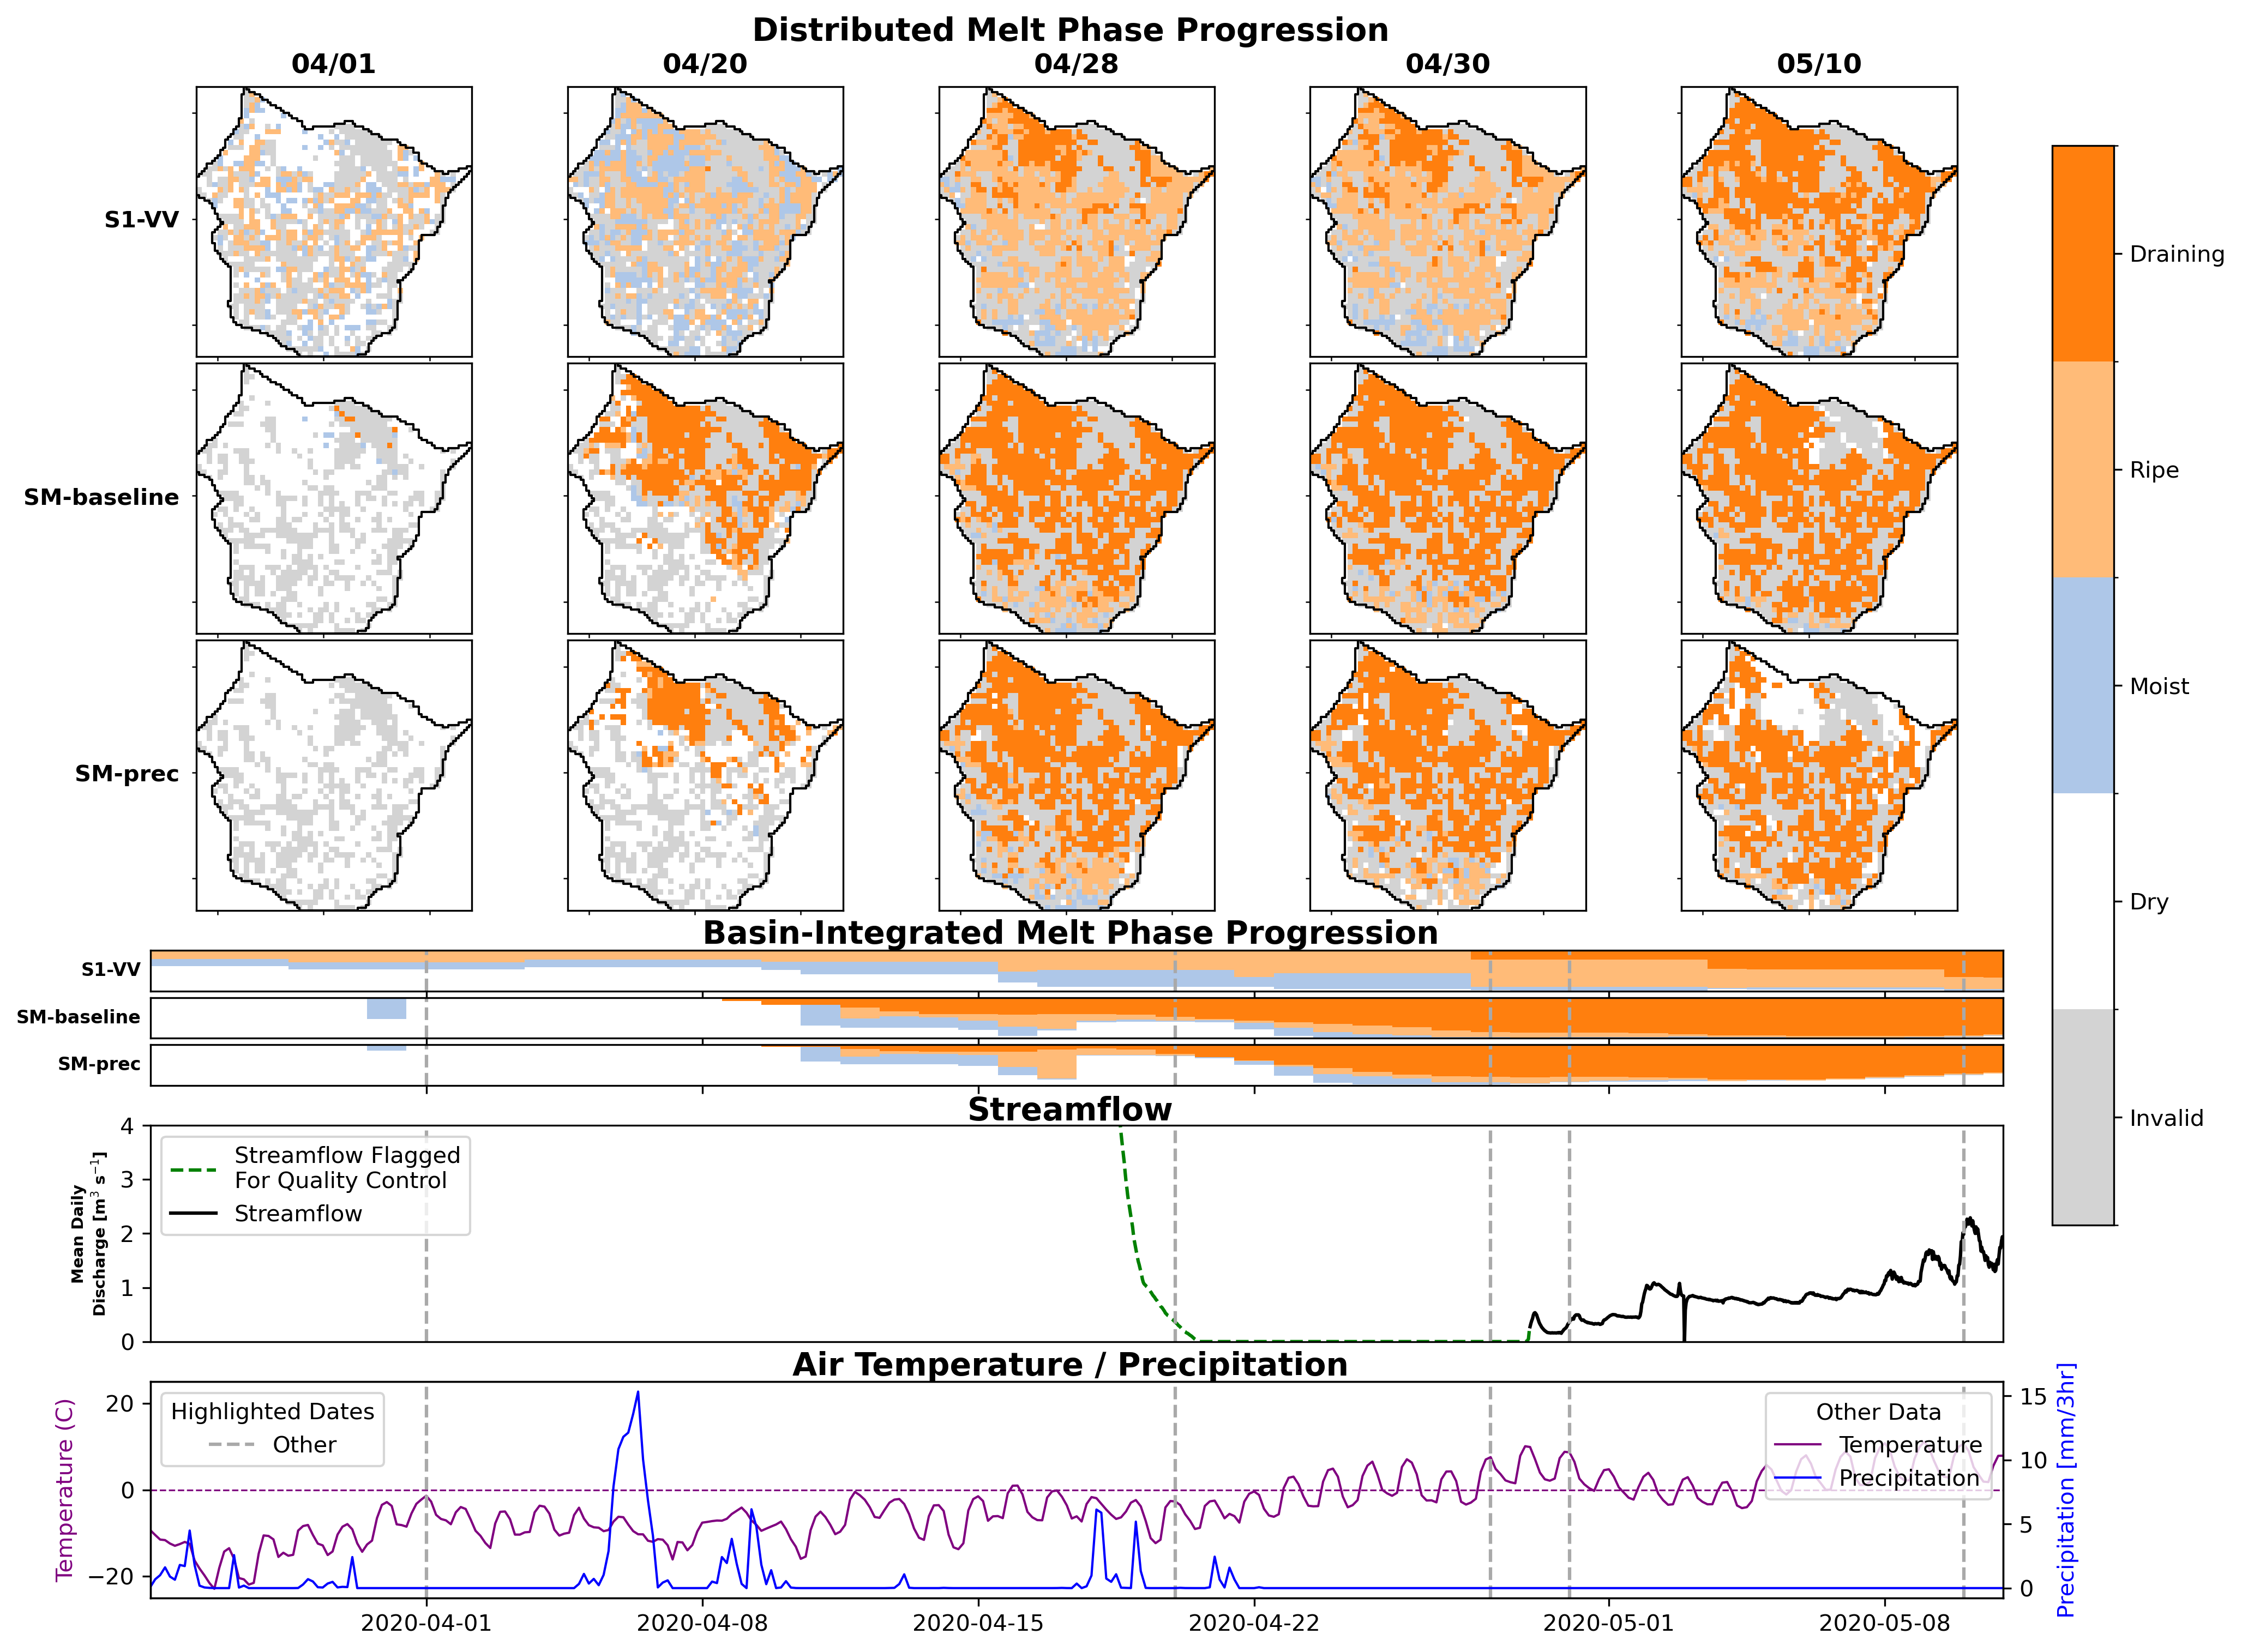

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import copy

date_lst = [f"{year}-04-01",f"{year}-04-20",f"{year}-04-28", f"{year}-04-30",f"{year}-05-10"] # 2017
# date_lst = [f"{year}-03-15", f"{year}-04-07",f"{year}-05-15"] # 2018

model_lst = [ds_s1_rc_match_rc, ds_sm_bl_match_rc, ds_sm_op_match_rc]
model_names = ["S1-VV", "SM-baseline", "SM-prec"]
# stream_slice = streamflow_lyell_df[(streamflow_lyell_df.Date_Time >= np.datetime64(f'{year}-03-01')) & (streamflow_lyell_df.Date_Time <= np.datetime64(f'{year}-07-01'))][['Date_Time','Estimated_Discharge']] # 2018
stream_slice = streamflow_lyell_df[(streamflow_lyell_df.Date_Time >= np.datetime64(f'{year}-03-25')) & (streamflow_lyell_df.Date_Time <= np.datetime64(f'{year}-05-11'))][['Date_Time','Estimated_Discharge','Discharge_Flag']] # 2018
aso_basin = aso_ds.where(aso_ds.date.dt.year == year,drop = True)['aso_swe'].rio.write_crs(aso_crs).rio.clip(lyell_gdf_proj.geometry)
aso_dates = [str(i)[0:10] for i in aso_basin.date.values]

x_start = pd.to_datetime(f"{year}-03-25")
x_end   = pd.to_datetime(f"{year}-05-11")

wrf_temp_df = wrf_temp.where(wrf_temp.Time >= x_start,drop = True).where(wrf_temp.Time <= x_end,drop = True).to_dataframe().drop(columns = ['XLAT','XLONG']).reset_index()
wrf_p_df = wrf_p.where(wrf_p.Time >= x_start,drop = True).where(wrf_p.Time <= x_end,drop = True).to_dataframe().drop(columns = ['XLAT','XLONG']).reset_index()


# ==========================================================
# Create figure layout
# ==========================================================
fig = plt.figure(
    figsize=(len(date_lst)*3, len(model_lst)*4),
    dpi=300
)

gs = fig.add_gridspec(
    nrows=11,
    ncols=len(date_lst),
    height_ratios=[1, 1, 1,0.1,0.15,0.15,0.15,0.1,0.8,0.1,0.8],  # bottom row slightly shorter
    hspace=0.05,
    wspace=0.01
)

# Top 3x4 map panels
ax = np.empty((len(model_lst), len(date_lst)), dtype=object)

for r in range(len(model_lst)):
    for c in range(len(date_lst)):
        if r == 0 and c == 0:
            ax[r, c] = fig.add_subplot(gs[r, c])
        else:
            ax[r, c] = fig.add_subplot(
                gs[r, c],
                sharex=ax[0, 0],
                sharey=ax[0, 0]
            )

# New bottom subplot spanning all columns
ax_phase_t = fig.add_subplot(gs[3, :])
ax_q_t = fig.add_subplot(gs[7, :])
ax_p_t_t = fig.add_subplot(gs[9, :])
ax_phase_t.axis('off')
ax_q_t.axis('off')
ax_p_t_t.axis('off')
ax_bottom = fig.add_subplot(gs[8, :])
ax_bottom2 = fig.add_subplot(gs[10, :])

phase_strip_axes = [
    fig.add_subplot(gs[4, :]),
    fig.add_subplot(gs[5, :]),
    fig.add_subplot(gs[6, :]),
]

# ==========================================================
# Existing plotting code (unchanged)
# ==========================================================
# ==========================================================
# Model phase maps
# ==========================================================
method_phase_dict = {}

for count, date_str in enumerate(date_lst):
    for model in range(len(model_lst)):

        mappable, phase_save = plot_distributed_phase_date(
            model_lst[model],
            date_str,
            ax[model, count],
            twoWkAgg=False,
            clpShape=lyell_gdf_proj,
            directMask=True,
        )

        if count == 0:
            method_phase_dict[model_names[model]] = phase_save.where(phase_save >= -1)

        lyell_gdf_proj.plot(ax=ax[model, count], color="none", edgecolor="black")

        if model == 0:
            ax[model, count].set_title(
                date_str[5:10].replace("-", "/"),
                fontweight="bold"
            )
        else:
            ax[model, count].set_title("")

        if count == 0:
            ax[model, count].set_ylabel(model_names[model], 
                                        fontweight="bold",
                                        rotation = 0,
                                        ha="right",
                                        va="center",
                                        labelpad=2)
        else:
            ax[model, count].set_ylabel("")

        ax[model, count].set_xticks([])
        ax[model, count].set_xlabel("")
        ax[model, count].set_yticks([])

# ==========================================================
# Phase fraction strips
# ==========================================================
phase_codes_bar  = [0, 1, 2, 3]
phase_labels_bar = ["Dry", "Moist", "Ripe", "Output"]

phase_colors_bar = {
    "Dry": "white",
    "Moist": "#AEC7E8",
    "Ripe": "#FFBB78",
    "Output": "#FF7F0E",
}

def calc_phase_frac_no_invalid(phase_da):
    valid = np.isfinite(phase_da) & (phase_da >= 0)

    frac_list = []
    for code in phase_codes_bar:
        frac = (
            ((phase_da == code) & valid).sum(dim=("y", "x"))
            / valid.sum(dim=("y", "x"))
        ) * 100
        frac_list.append(frac)

    return xr.concat(frac_list, dim="phase").assign_coords(phase=phase_labels_bar)

count = 0
for ax_phase, (method_name, phase_da) in zip(phase_strip_axes, method_phase_dict.items()):

    phase_frac = calc_phase_frac_no_invalid(phase_da)
    time_vals = pd.to_datetime(phase_frac.time.values)
    bottom = np.zeros(len(time_vals))

    for phase_name, color in phase_colors_bar.items():
        vals = phase_frac.sel(phase=phase_name).values

        ax_phase.fill_between(
            time_vals,
            bottom,
            bottom + vals,
            color=color,
            step="mid",
            linewidth=0,
        )

        bottom += vals

    ax_phase.set_ylim(0, 100)
    ax_phase.set_xlim(x_start, x_end)
    ax_phase.set_yticks([])
    ax_phase.tick_params(axis="x", labelbottom=False)
    ax_phase.set_ylabel(
        method_name,
        rotation=0,
        ha="right",
        va="center",
        fontsize=8,
        fontweight='bold',
    )
    if count == 0:
        pass
        # ax_phase.set_title('Basin phase Evolution', fontweight = 'bold', fontsize = 0,pad=1)

    for date_str in date_lst:
        ax_phase.axvline(pd.to_datetime(date_str), color="darkgray", linestyle="--")

    # for aso_date in aso_dates:
    #     ax_phase.axvline(pd.to_datetime(aso_date), color="red", linestyle="--", linewidth=1.5)
    count += 1

# ==========================================================
# Placeholder for future bottom panel
# ==========================================================
stream_slice[stream_slice['Discharge_Flag'] != 0].plot(ax=ax_bottom,x = 'Date_Time',y = 'Estimated_Discharge',label = 'Streamflow Flagged\nFor Quality Control',color ='green',linestyle = '--')
stream_slice[stream_slice['Discharge_Flag'] == 0].plot(ax=ax_bottom,x = 'Date_Time',y = 'Estimated_Discharge',label = 'Streamflow',color ='black')
for date_str in date_lst:
    ax_bottom.axvline(np.datetime64(date_str),color = 'darkgray',linestyle = '--')
for aso_date in aso_dates:
    pass
    # ax_bottom.axvline(np.datetime64(aso_date),color = 'red',linestyle = '--')
# ax_bottom.set_title(
#     "Stream Discharge",
#     fontweight="bold"
# )
ax_bottom.set_ylim(0,4)
ax_bottom.set_xlim(x_start, x_end)
ax_bottom.set_xlabel('')
ax_bottom.set_ylabel(
    "Mean Daily\n"+r"Discharge [m$^3$ s$^{-1}$]",
    fontsize=7,
    fontweight="bold"
)
ax_bottom.tick_params(
    axis="x",
    which="both",
    bottom=False,
    labelbottom=False,
)

tl, = ax_bottom2.plot(wrf_temp_df.Time,wrf_temp_df.T2,color = 'purple',linewidth = 1)
ax_bottom2.axhline(0,linestyle = '--',color = 'purple',linewidth = 0.75)
ax_bottom2.set_ylim(-25,25)
ax_bottom2.set_ylabel('Temperature (C)',color = 'purple')
ax_bottom2.set_xlim(x_start, x_end)
count = 0
for date_str in date_lst:
    hd = ax_bottom2.axvline(np.datetime64(date_str),color = 'darkgray',linestyle = '--')
    count += 1
leg1 = ax_bottom2.legend(handles = [hd],labels = ['Other'],title = 'Highlighted Dates')
ax_bottom2.add_artist(leg1)

ax_bottom3 = ax_bottom2.twinx()
tp, = ax_bottom3.plot(wrf_p_df.Time,wrf_p_df.PREC_ACC_NC,color = 'blue',linewidth = 1)
ax_bottom3.set_xlim(x_start, x_end)
ax_bottom3.set_ylabel('Precipitation [mm/3hr]',color = 'blue')
ax_bottom2.legend(handles = [tl,tp],labels = ['Temperature','Precipitation'],title = 'Other Data',loc = 'upper right')

# ==========================================================
# Shared colorbar
# ==========================================================
fig.subplots_adjust(right=0.88)

cax = fig.add_axes([0.90, 0.30, 0.025, 0.55])

cbar = fig.colorbar(mappable, cax=cax)

cbar.set_ticks([-1, 0, 1, 2, 3])
cbar.set_ticklabels([
    "Invalid",
    "Dry",
    "Moist",
    "Ripe",
    "Draining"
])

cbar.set_label("")
fig.text(
    0.5,
    0.90,  # tune if needed
    "Distributed Melt Phase Progression",
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold"
)
fig.text(
    0.5,
    0.44,  # tune if needed
    "Basin-Integrated Melt Phase Progression",
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold"
)
fig.text(
    0.5,
    0.35,  # tune if needed
    "Streamflow",
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold"
)
fig.text(
    0.5,
    0.22,  # tune if needed
    "Air Temperature / Precipitation",
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold"
)
plt.savefig("./pngs/S14_lyell_melt_progression_2020_VV.png",dpi=300,bbox_inches="tight",pad_inches=0.1) 
plt.show()